In [1]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm

In [2]:
tau = 2
print(np.abs(u_tilde(tau,pi/2,tau))**2)
print(np.abs(v_tilde(tau,pi/2,tau))**2)



NameError: name 'u_tilde' is not defined

In [ ]:
L = 1000
taus = np.logspace(-2,2.5,50)
x=[]
for tau in tqdm(taus):
    t = -1000*tau

    s = state(L,tau,t)

    x+=[D(1,s)]
plt.plot(taus,x)
#plt.plot(taus,(4*pi*taus)**(-1/2))
print(x)

  0%|          | 0/50 [00:00<?, ?it/s]


NameError: name 'state' is not defined

In [ ]:
def u_tilde(tau,q,t):
    a = 1+cos(q)
    b = sin(q)
    rot = exp(-1j*3*pi/4)
    rot_inv = exp(1j*3*pi/4)
    decay = exp(-pi*b*b*tau/4)

    prefactor = rot*b*sqrt(tau)*decay
    argument = rot_inv*2*(t-a*tau)/sqrt(tau)

    nu = 1j*b*b*tau-1

    return prefactor*complex(pcfd(nu,argument))

def v_tilde(tau,q,t):
    a = 1+cos(q)
    b = sin(q)
    rot = exp(-1j*3*pi/4)
    rot_inv = exp(1j*3*pi/4)

    decay = exp(-pi*b*b*tau/4)

    prefactor = -decay
    argument = rot_inv*2*(t-a*tau)/sqrt(tau)

    nu = 1j*b*b*tau

    return prefactor*complex(pcfd(nu,argument))

In [4]:
v_tilde(100,0,-100)

np.complex128(-0.06624670220309174-0.9978032744219749j)

In [5]:
def u_diag(q,g):
    a = g+cos(q)
    omega= sqrt(g*g+2*g*cos(q)+1)

    denom = sqrt(2*omega*(omega-a))

    return (a - omega)/denom

def v_diag(q,g):
    a = g+cos(q)
    b = sin(q)
    omega= sqrt(g*g+2*g*cos(q)+1)

    denom = sqrt(2*omega*(omega-a))

    return b/denom

In [6]:

def k_vals(L):
    x=(2 * np.arange(-L//2, L//2) + 1) * np.pi / (L)
    return x[x>0]


def state(L,tau,t):
    k = k_vals(L)
    us = []
    vs = []
    for q in k:
        us.append(u_tilde(tau,q,t))
        vs.append(v_tilde(tau,q,t))
    us = np.array(us)
    vs = np.array(vs)
    return [us,vs,k]


def ground_state(L,tau,t):
    def g(t,tau):
        return -t/tau + 1
    k = k_vals(L)
    us = []
    vs = []
    for q in k:
        v = v_diag(q,g(t,tau))
        u = u_diag(q,g(t,tau))#1-np.abs(v)**2

        norm = sqrt(u**2+v**2)
        us.append(u/norm)
        vs.append(v/norm)
    us = np.array(us)
    vs = np.array(vs)
    return [us,vs,k]

def G(r,state):
    ##The fix to this function seems to be making the second term have an addition sign...
    u_tilde = state[0]
    v_tilde = state[1]
    k_vals = state[2]
    u = state[0]
    v = state[1]
    k = state[2]

    Gr = 2*cos(k*r)*(np.abs(u)**2-np.abs(v)**2)-2j*sin(k*r)*(np.conj(u)*v+v*np.conj(u))
    #full_sum = 0

    # for j,k in enumerate(k_vals):
    #     u = u_tilde[j]
    #     v = v_tilde[j]
    #     full_sum += (2  *  cos(k*r)  *  (np.abs(u)**2-np.abs(v)**2)
    #                  -2j* sin(k*r)*   (np.conj(u)*v+  v*np.conj(u)))
        
    # return -full_sum/(2*len(k_vals))
    return -np.mean(Gr)/2

def D(n,state):
    r = n+1
    return G(r,state)


In [7]:
def sigma_general(indices,state):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,state)
    return np.linalg.det(C)

  0%|          | 0/50 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_89439/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 50/50 [00:02<00:00, 20.87it/s]


(0.0, 1.1)

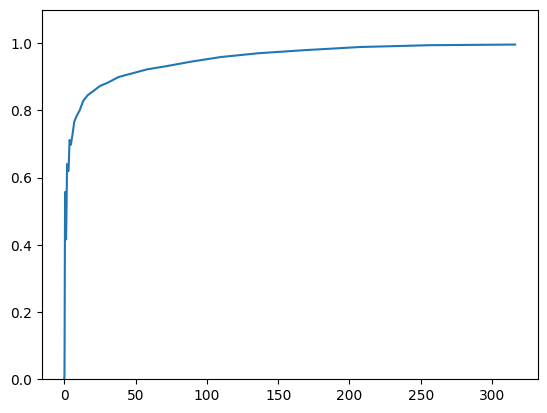

In [451]:
x=[]
for tau in tqdm(2*taus):
    t = tau

    s = state(L,tau,t)
    x+=[sigma_general([0,1,2,3,4,5],s)]
x=np.array(x)
plot(taus,x*8)
plt.ylim(0,1.1)

(0.0, 1.0)

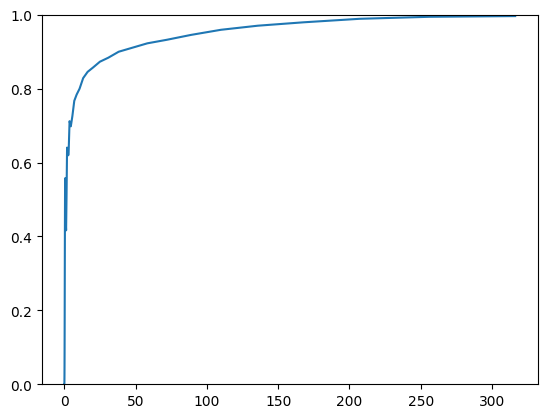

In [383]:
plt.plot(taus,8*x)
plt.ylim(0,1)

In [9]:
import sys
sys.path.append("../../src/")

import kblock_ising_model as kb
def g(t,tau):
    return -t/tau + 1

In [10]:
#Setting Constants
tau = 1
L = 100
t = tau*-999999
indices = [0,1]
####
#Evaluate G0
g0 = g(t,tau)
print(g0)



1000000.0


In [614]:
#Evaluate kb.sigma(general)
k_vals_groundstate = kb.k_vals(L)
U_groundstate = kb.U(k_vals_groundstate,-g0)
kb_sigmaxx=  kb.sigma_general(indices,U_groundstate,k_vals_groundstate)

INDEX = 1

#Evaluate Ground state using formulas from reference
ground_state_this_notebook = ground_state(L,tau,t)
print("KB result")
print(U_groundstate[INDEX][k_vals_groundstate>0])
print("BDG result")
print(ground_state_this_notebook[INDEX])

KB result
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
BDG result
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


In [569]:
#Evaluate kb.sigma(general)
k_vals_groundstate = kb.k_vals(L)
U_groundstate = kb.U(k_vals_groundstate,-g0)
gs = ground_state(L,tau,t)


KBT=  kb.sigma_general(indices,U_groundstate,k_vals_groundstate)
BDGT = sigma_general([0,1],gs)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_89439/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


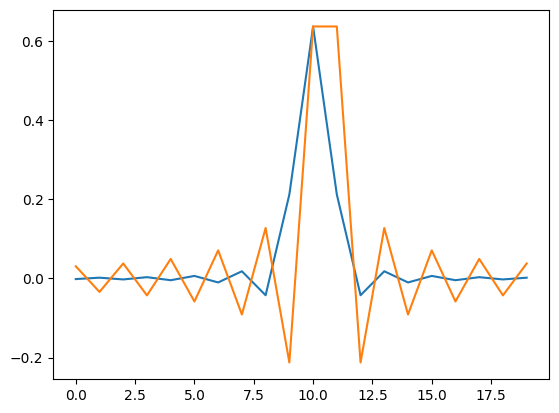

In [570]:
plot([G(xi,gs) for xi in np.arange(-10,10)])
plot([kb.BA([U_groundstate,k_vals_groundstate,xi]) for xi in np.arange(-10,10)])

In [606]:
#Desperately confused

def G_exact(r,l):
    k = np.linspace(-pi,pi,1000)

    x = 0 
    for ki in k:
        ff=exp(1j*ki*r)
        arg1= 1+(l)*exp(1j*ki)
        arg2 = 1+(l)*exp(-1j*ki)

        x+= ff*np.exp(0.5 * np.log(arg1 / arg2))
    return x/len(k)

In [608]:
G_exact(0,1000000000000)

np.complex128(0.6369834146567408-1.457472963177399e-16j)

In [610]:
print(G_exact(0, 0))       # should be ~1
print(G_exact(1, 0))       # should be ~0
print(G_exact(-1, 1e10))   # should be ~1
#print(G_exact(r, 1))       # should match (2/pi) * (-1)**r / (2*r + 1)


(1+0j)
(-0.0009999999999999753+6.334879857057941e-17j)
1.629303680190454e-18j


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


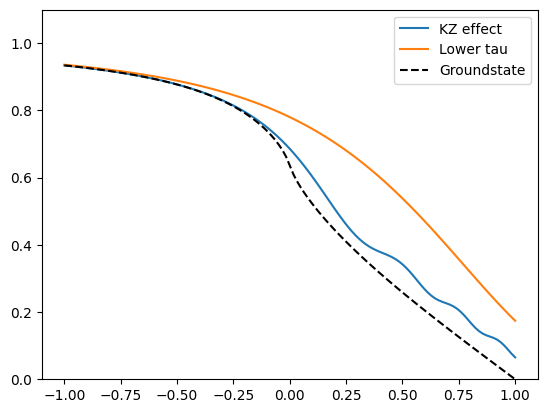

In [11]:
tau =10
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat=[]
dat2=[]
for t in times:
    gdat.append(g(t,tau))

    dat.append(G(0,state(L,tau,t)))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))

    dat2.append(kb.BA([UU,ku,0]))

tau =1
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat3=[]
for t in times:
    dat3.append(G(0,state(L,tau,t)))

plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,1.1)

plt.legend()

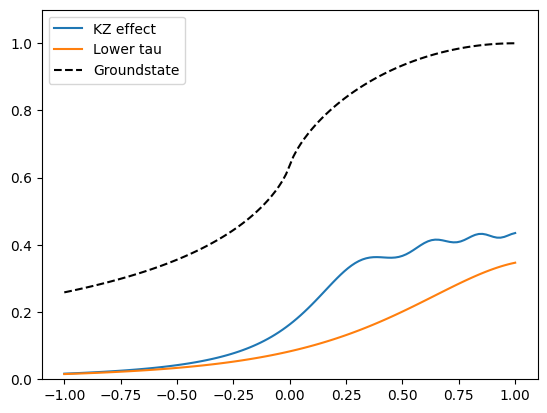

In [744]:
tau =10
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat=[]
dat2=[]
for t in times:
    gdat.append(g(t,tau))

    dat.append(G(1,state(L,tau,t)))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))

    dat2.append(kb.BA([UU,ku,1]))

tau =1
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat3=[]
for t in times:
    dat3.append(G(1,state(L,tau,t)))

plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,1.1)

plt.legend()

In [821]:
def G(r,state):
    u_tilde = state[0]
    v_tilde = state[1]
    k_vals = state[2]
    
    full_sum = 0
    for j,k in enumerate(k_vals):
        u = u_tilde[j]
        v = v_tilde[j]
        full_sum += (2  *  cos(k*r)  *  (np.abs(u)**2-np.abs(v)**2)
                     -2j* sin(k*r)*   (np.conj(u)*v+  v*np.conj(u)))
        
       # t1 = 2  *  cos(k*r)  *  (np.abs(u)**2-np.abs(v)**2)
        #t2 = -2j* sin(k*r)*   (np.conj(u)*v+  v*np.conj(u))
        #print(f"TERM 1 ={t1} ")
        #print(f"TERM 2= {t2}")
    return -full_sum/(2*len(k_vals))

In [ ]:
tau= 10
t = tau
L=10
state(L,tau,t)

u = u_tilde(tau,pi/2,t)
v=  v_tilde(tau,pi/2,t)




np.complex128(0j)

In [814]:
tau =10
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat=[]
dat2=[]
for t in times:
    gdat.append(g(t,tau))

    dat.append(G(0,state(L,tau,t)))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))

    dat2.append(kb.BA([UU,ku,0]))

tau =1
times = np.linspace(-tau,tau,125)
L = 150
gdat=[]
dat3=[]
for t in times:
    dat3.append(G(0,state(L,tau,t)))


TERM 1 =-1.999951264874599 
TERM 2= 0j
TERM 1 =-1.999561512185354 
TERM 2= -0j
TERM 1 =-1.9987826914586069 
TERM 2= 0j
TERM 1 =-1.9976161734688889 
TERM 2= -0j
TERM 1 =-1.9960640180663312 
TERM 2= 0j
TERM 1 =-1.9941289786287835 
TERM 2= 0j
TERM 1 =-1.991814508042037 
TERM 2= 0j
TERM 1 =-1.989124766246923 
TERM 2= 0j
TERM 1 =-1.9860646294011264 
TERM 2= 0j
TERM 1 =-1.9826397007134493 
TERM 2= 0j
TERM 1 =-1.9788563230207001 
TERM 2= 0j
TERM 1 =-1.9747215931859547 
TERM 2= 0j
TERM 1 =-1.97024337840943 
TERM 2= 0j
TERM 1 =-1.9654303345541329 
TERM 2= 0j
TERM 1 =-1.960291926601504 
TERM 2= 0j
TERM 1 =-1.9548384513629007 
TERM 2= 0j
TERM 1 =-1.9490810625875923 
TERM 2= 0j
TERM 1 =-1.9430317986177963 
TERM 2= 0j
TERM 1 =-1.9367036127586024 
TERM 2= 0j
TERM 1 =-1.9301104065388308 
TERM 2= 0j
TERM 1 =-1.9232670660558133 
TERM 2= 0j
TERM 1 =-1.9161895016064365 
TERM 2= 0j
TERM 1 =-1.908894690819158 
TERM 2= 0j
TERM 1 =-1.9014007255109022 
TERM 2= 0j
TERM 1 =-1.89372686249838 
TERM 2= 0j
TERM 1 =

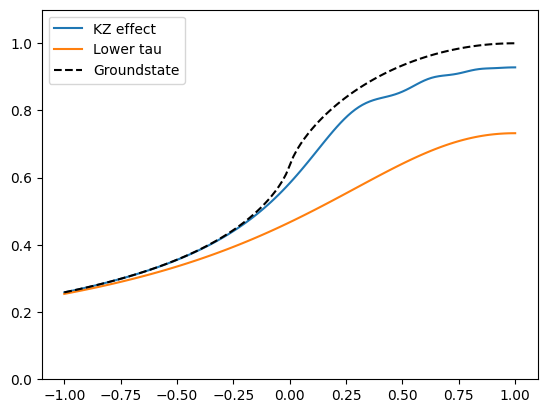

In [812]:
dat = np.array(dat)
dat2= np.array(dat2)
dat3 = np.array(dat3)



plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,1.1)

plt.legend()

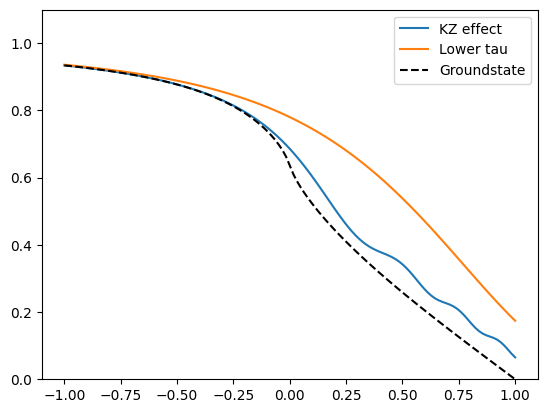

In [815]:
dat = np.array(dat)
dat2= np.array(dat2)
dat3 = np.array(dat3)



plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,1.1)

plt.legend()

In [865]:
tau =10
times = np.linspace(-tau,tau,50)
L = 150
gdat=[]
dat=[]
dat2=[]
for t in times:
    gdat.append(g(t,tau))
    s = state(L,tau,t)
    dat.append(sigma_general([0,1,2,6],s))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))
    dat2.append(kb.sigma_general([0,1,2,6],UU,ku))
tau =1
times = np.linspace(-tau,tau,50)
L = 150
gdat=[]
dat3=[]
for t in times:
    s = state(L,tau,t)
    dat3.append(sigma_general([0,1,2,6],s))


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_89439/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


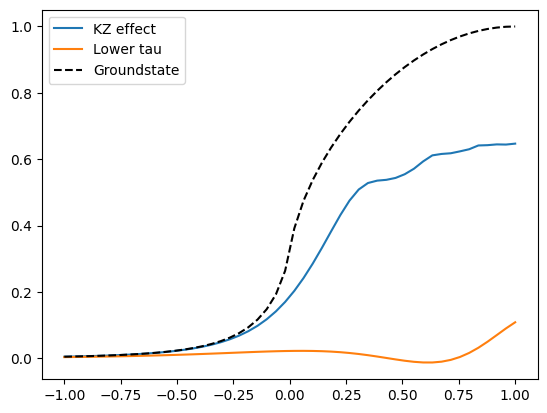

In [866]:
dat = np.array(dat)
dat2= np.array(dat2)
dat3 = np.array(dat3)



plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

#plt.ylim(0,1.1)

plt.legend()

In [8]:
##Projector Functions 
from itertools import combinations
from collections import Counter

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,state, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,state)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n


In [13]:
tau =25
n=6

times = np.linspace(-tau,tau,50)
L = 150
gdat=[]
dat=[]
dat2=[]
dat3=[]
for t in times:
    gdat.append(g(t,tau))
    s = state(L,tau,t)
    dat.append(P_n(n,s))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))
    dat2.append(kb.P_n(n,UU,ku))
tau =1
times = np.linspace(-tau,tau,50)
dat3=[]
for t in times:
    s = state(L,tau,t)
    dat3.append(P_n(n,s))


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12117/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


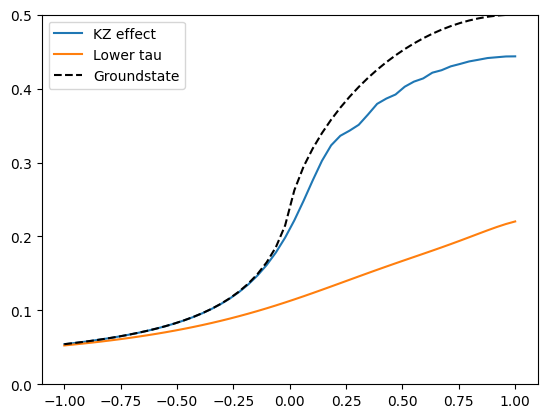

In [14]:
dat = np.array(dat)
dat2= np.array(dat2)
dat3 = np.array(dat3)



plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,0.5)

plt.legend()

In [11]:
tau =2
n=2

times = np.linspace(-tau,tau,50)
L = 150
gdat=[]
dat=[]
dat2=[]
dat3=[]
for t in times:
    gdat.append(g(t,tau))
    s = state(L,tau,t)
    dat.append(P_n(n,s))
    ku = kb.k_vals(L)
    UU =kb.U(ku,-g(t,tau))
    dat2.append(kb.P_n(n,UU,ku))
tau =1
times = np.linspace(-tau,tau,50)
dat3=[]
for t in times:
    s = state(L,tau,t)
    dat3.append(P_n(n,s))


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12427/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


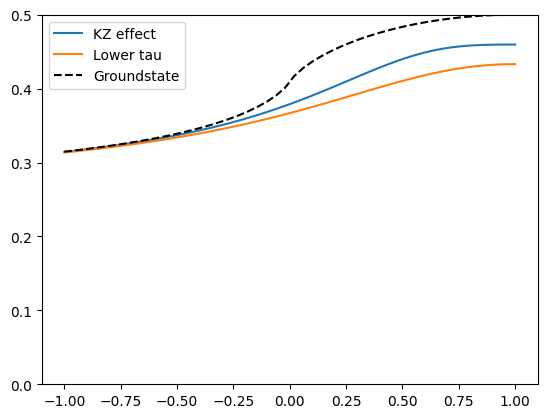

In [12]:
dat = np.array(dat)
dat2= np.array(dat2)
dat3 = np.array(dat3)



plt.plot(times,dat,label="KZ effect")
plt.plot(times,dat3,label="Lower tau")
plt.plot(times,dat2,label="Groundstate",color="Black",linestyle="--")

plt.ylim(0,0.5)

plt.legend()

In [14]:
def delta(state,args,n):
    KZ = P_n(n,state)
    GS = kb.P_n(n,*args)
    return KZ-GS


In [22]:
L = 150
tau = 10
t  = tau
g0 = g(t,tau)
s = state(L,tau,t)

k0 = kb.k_vals(L)
U0 = kb.U(k0,g0)

delta(s,[U0,k0],2)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12427/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


np.float64(-0.017926505640139423)

In [30]:
tau =10
n=2

times = np.linspace(-tau,tau,50)
L = 150
gdat=[]
dat=[]
dat2=[]
dat3=[]
for t in times:
    gdat.append(g(t,tau))
    k0 = kb.k_vals(L)

    s = state(L,tau,t)
    U0 =kb.U(ku,-g(t,tau))
    dat.append(delta(s,[U0,k0],2))
    dat2.append(delta(s,[U0,k0],4))
    dat3.append(delta(s,[U0,k0],8))




/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12427/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


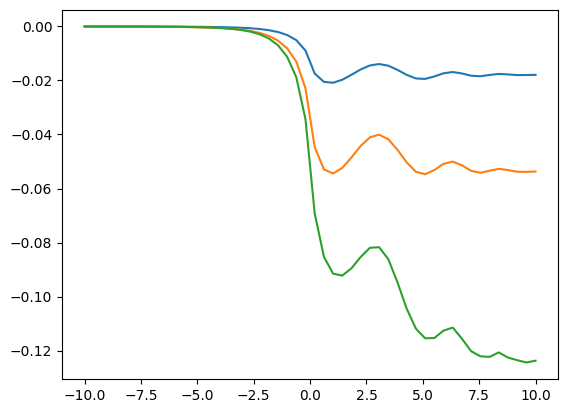

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12427/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


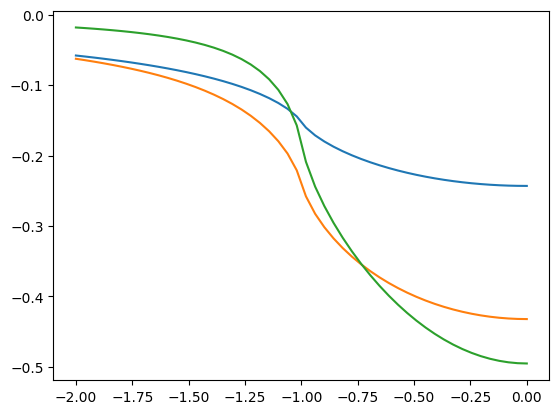

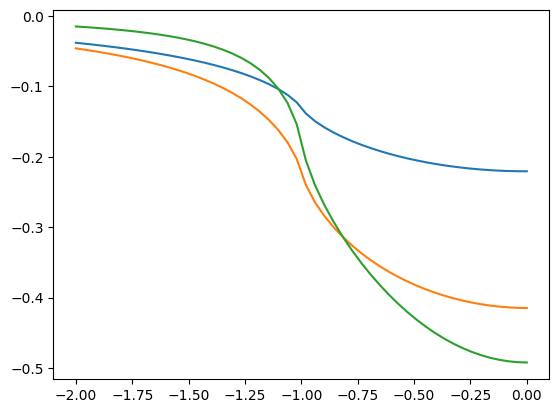

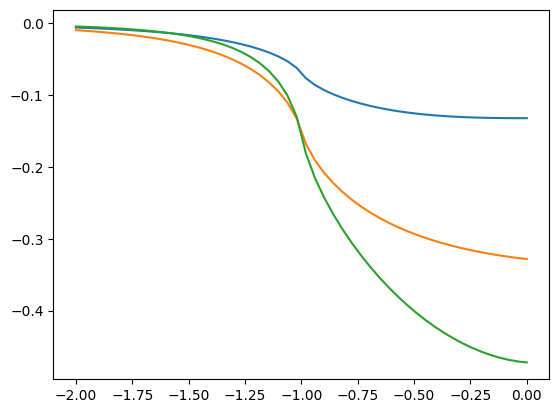

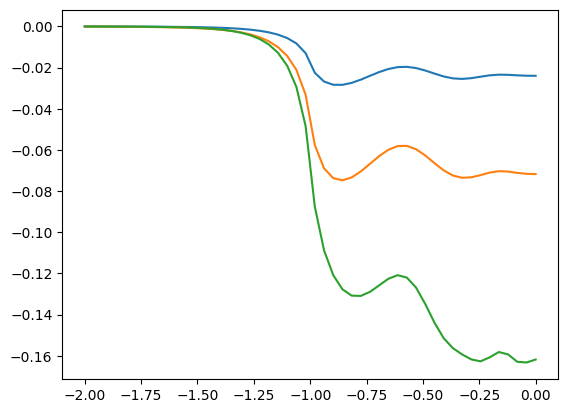

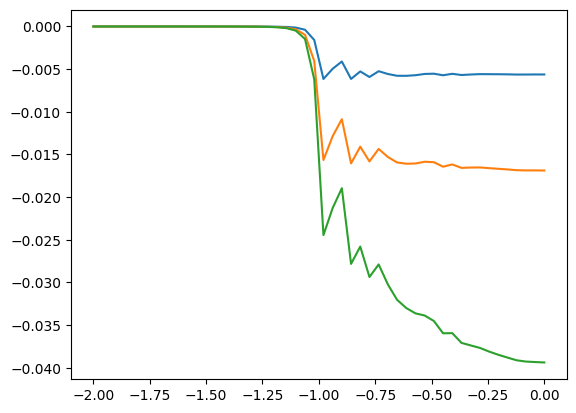

In [42]:
tau =10
n=2

for tau in np.logspace(-3,2,5):


    times = np.linspace(-tau,tau,50)
    L = 150
    gdat=[]
    dat=[]
    dat2=[]
    dat3=[]
    for t in times:
        gdat.append(g(t,tau))
        k0 = kb.k_vals(L)

        s = state(L,tau,t)
        U0 =kb.U(ku,-g(t,tau))
        dat.append(delta(s,[U0,k0],2))
        dat2.append(delta(s,[U0,k0],4))
        dat3.append(delta(s,[U0,k0],8))
    gdat=np.array(gdat)
    plot(-gdat,dat)
    plot(-gdat,dat2)
    plot(-gdat,dat3,label="tau")
    plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_12427/2288753519.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 25/25 [01:49<00:00,  4.38s/it]


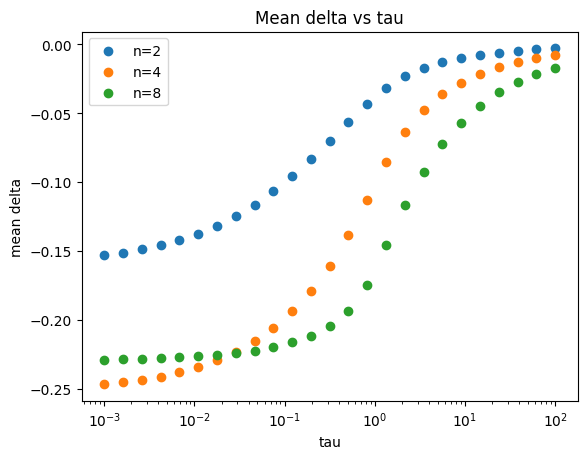

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

taus = np.logspace(-3, 2, 25)
L = 150

tau_vals = []
means_n2 = []
means_n4 = []
means_n8 = []

for tau in tqdm(taus):
    times = np.linspace(-tau, tau, 50)
    gdat = []
    dat = []
    dat2 = []
    dat3 = []

    for t in times:
        gval = g(t, tau)
        gdat.append(gval)

        k0 = kb.k_vals(L)
        s = state(L, tau, t)
        U0 = kb.U(k0, -gval)

        dat.append(delta(s, [U0, k0], 2))
        dat2.append(delta(s, [U0, k0], 4))
        dat3.append(delta(s, [U0, k0], 8))

    gdat = np.array(gdat)
    dat = np.array(dat)
    dat2 = np.array(dat2)
    dat3 = np.array(dat3)

    # plot(-gdat, dat)
    # plot(-gdat, dat2)
    # plot(-gdat, dat3, label=f"tau={tau}")
    # plt.legend()
    # plt.show()

    tau_vals.append(tau)
    means_n2.append(np.mean(dat))
    means_n4.append(np.mean(dat2))
    means_n8.append(np.mean(dat3))

# Final scatter plot
plt.scatter(tau_vals, means_n2, label='n=2')
plt.scatter(tau_vals, means_n4, label='n=4')
plt.scatter(tau_vals, means_n8, label='n=8')
plt.xscale('log')
plt.xlabel("tau")
plt.ylabel("mean delta")
plt.legend()
plt.title("Mean delta vs tau")
plt.show()


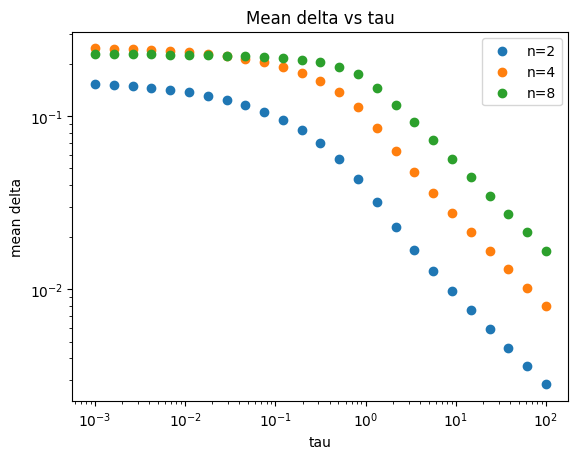

In [49]:
# Final scatter plot

plt.scatter(tau_vals, -np.array(means_n2), label='n=2')
plt.scatter(tau_vals, -np.array(means_n4), label='n=4')
plt.scatter(tau_vals, -np.array(means_n8), label='n=8')
plt.xscale('log')
plt.xlabel("tau")
plt.ylabel("mean delta")
plt.legend()
plt.title("Mean delta vs tau")
plt.yscale("log")
plt.show()
